# Key-affinity stickiness analysis (experiment 49)

Checks whether router **conversation key-affinity** actually kept every turn of a
chat on the **same vLLM pod** (the whole point of `router_strategy: affinity`,
`router_affinity_mode: hard`).

Data source: `<EXPERIMENTS_ROOT>/<EXP_ID>/logs.json` (one record per request, joined
by `router_log_collector` so `endpoint_id`, `kv_hit`, `matched_tokens` are present).
yz: `/home/data/saeid/experiments` · bz: `/data/experiments`.

Per-request fields we rely on:
- `conversation_id`, `turn_idx`, `num_turns` — multi-turn structure
- `affinity_key` — the `sk-bench-<n>` key the router pins on
- `endpoint_id` — the pod that actually served the request
- `kv_hit`, `matched_tokens`, `kv_hits_len`, `total_blocks` — prefix reuse
- `ttft_s`, `end_to_end_s`, `prompt_tokens` — latency payoff

**How to run:** set `EXP_ID` below, run all, then screenshot the summary table +
the 4 plots back into chat so we can decide if stickiness was good enough.

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

EXP_ID = 49
# Experiment output root. yz prod runs (prod_latency_collector.py) write here:
#   yz: /home/data/saeid/experiments   |  bz: /data/experiments
EXPERIMENTS_ROOT = "/home/data/saeid/experiments"

# Fields we pull straight out of logs.json (raw, so affinity/kv fields survive).
_FIELDS = [
    "idx", "req_id", "conversation_id", "turn_idx", "num_turns",
    "affinity_key", "endpoint_id",
    "kv_hit", "matched_tokens", "kv_hits_len", "total_blocks",
    "ttft_s", "end_to_end_s", "model_latency_s",
    "prompt_tokens", "completion_tokens", "total_tokens",
    "t0_wall", "t1_wall",
    "send_failed",
]


def load_logs(exp_id, experiments_root=EXPERIMENTS_ROOT, include_failed=False):
    path = Path(experiments_root) / str(exp_id) / "logs.json"
    if not path.is_file():
        raise FileNotFoundError(f"logs.json not found: {path}")
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rec = json.loads(line)
            if rec.get("send_failed") and not include_failed:
                continue
            rows.append({k: rec.get(k) for k in _FIELDS})
    df = pd.DataFrame(rows)
    # conversation grouping key: conversation_id, else affinity_key
    df["group"] = df["conversation_id"]
    df.loc[df["group"].isna(), "group"] = df["affinity_key"]
    df["group"] = df["group"].astype("string")
    for c in ["turn_idx", "num_turns", "matched_tokens", "kv_hits_len",
              "total_blocks", "prompt_tokens", "total_tokens"]:
        if c in df:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    for c in ["ttft_s", "end_to_end_s", "model_latency_s", "t0_wall", "t1_wall"]:
        if c in df:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df


df = load_logs(EXP_ID)
print(f"exp {EXP_ID}: {len(df)} requests, "
      f"{df['group'].nunique()} conversations, "
      f"{df['endpoint_id'].nunique()} endpoints seen")
print("has kv_hit:", df["kv_hit"].notna().any(),
      "| has turn_idx:", df["turn_idx"].notna().any(),
      "| has ttft:", df["ttft_s"].notna().any())
df.head()

exp 49: 4765 requests, 808 conversations, 2 endpoints seen
has kv_hit: True | has turn_idx: False | has ttft: True


,idx,req_id,conversation_id,turn_idx,num_turns,affinity_key,endpoint_id,kv_hit,matched_tokens,kv_hits_len,...,ttft_s,end_to_end_s,model_latency_s,prompt_tokens,completion_tokens,total_tokens,t0_wall,t1_wall,send_failed,group
0,0,dd9b5f1d22dd45f99303744ed4bfb7b2,None,NaN,NaN,a1a204f39ac364ab,vllm-minimax-m2-0,False,0,0,...,2.70984,8.34102,8.34102,27764,95,NaN,1.782849e+09,1.782849e+09,None,a1a204f39ac364ab
1,1,23e80e35690948c19855dd6bc8aeba00,None,NaN,NaN,5b137999dfc495a6,vllm-minimax-m2-1,False,0,0,...,2.71097,7.11974,7.11974,27446,65,NaN,1.782849e+09,1.782849e+09,None,5b137999dfc495a6
2,2,36c9c803a2214ceca2c61d0c72858850,None,NaN,NaN,a1a204f39ac364ab,vllm-minimax-m2-0,True,768,6,...,0.92429,2.30224,2.30224,27783,42,NaN,1.782849e+09,1.782849e+09,None,a1a204f39ac364ab
3,3,70946f755f624e5eab61972a8e4a2339,None,NaN,NaN,5b137999dfc495a6,vllm-minimax-m2-1,True,768,6,...,0.93032,2.58117,2.58117,27467,50,NaN,1.782849e+09,1.782849e+09,None,5b137999dfc495a6
4,4,787d76deed5e4f67ba8e2146ba03406a,None,NaN,NaN,a1a204f39ac364ab,vllm-minimax-m2-0,True,768,6,...,0.74912,2.08649,2.08649,27805,40,NaN,1.782849e+09,1.782849e+09,None,a1a204f39ac364ab


## 1. Stickiness summary

Mirrors `router_log_collector.summarize_routing`: group requests by conversation,
count how many **distinct pods** each conversation touched. Perfect hard-affinity
= every conversation lands on exactly **1** pod (`sticky_frac = 1.0`,
`avg_distinct_endpoints = 1.0`).

In [2]:
valid = df[df["endpoint_id"].notna() & df["group"].notna()].copy()

per_conv = (
    valid.groupby("group")
    .agg(
        requests=("req_id", "size"),
        distinct_endpoints=("endpoint_id", "nunique"),
        turns=("turn_idx", "max"),
        kv_hits=("kv_hit", lambda s: int(pd.Series(s).fillna(False).astype(bool).sum())),
    )
    .reset_index()
)
# only conversations with >1 request can actually be "spread"
multi = per_conv[per_conv["requests"] > 1]

n_groups = len(per_conv)
n_multi = len(multi)
sticky = int((multi["distinct_endpoints"] == 1).sum())

summary = {
    "total_requests": int(len(valid)),
    "conversations": n_groups,
    "multi_turn_conversations": n_multi,
    "sticky_conversations": sticky,
    "sticky_frac": round(sticky / n_multi, 4) if n_multi else None,
    "avg_distinct_endpoints": round(multi["distinct_endpoints"].mean(), 4) if n_multi else None,
    "max_distinct_endpoints": int(multi["distinct_endpoints"].max()) if n_multi else None,
    "overall_kv_hit_frac": (
        round(valid["kv_hit"].fillna(False).astype(bool).mean(), 4)
        if valid["kv_hit"].notna().any() else None
    ),
}
print(json.dumps(summary, indent=2))

# worst offenders: multi-turn conversations that bounced across pods
worst = multi.sort_values("distinct_endpoints", ascending=False).head(15)
print("\nLeast-sticky conversations (spread across pods):")
worst

{
  "total_requests": 4765,
  "conversations": 808,
  "multi_turn_conversations": 249,
  "sticky_conversations": 169,
  "sticky_frac": 0.6787,
  "avg_distinct_endpoints": 1.3213,
  "max_distinct_endpoints": 2,
  "overall_kv_hit_frac": 0.0256
}

Least-sticky conversations (spread across pods):


,group,requests,distinct_endpoints,turns,kv_hits
803,fea57b6cf517228c,5,2,NaN,0
204,3fb057be56665367,50,2,NaN,0
262,552275402c084425,7,2,NaN,0
256,5386e4d3453e47e5,11,2,NaN,0
623,c3a16e929a5c2e13,6,2,NaN,0
239,4b6cf73aa9e8dac8,17,2,NaN,0
645,c9b08d9ec830f169,28,2,NaN,0
651,cc3b8f1d5f920440,54,2,NaN,0
230,49aaee123269b86c,27,2,NaN,0
227,48c5139b4cfa8880,23,2,NaN,0


## 2. Distinct pods per conversation

Histogram: how many pods each multi-turn conversation touched. Ideal = a single
bar at `1`. Any mass at `>=2` is affinity leakage (turns bounced to another pod).

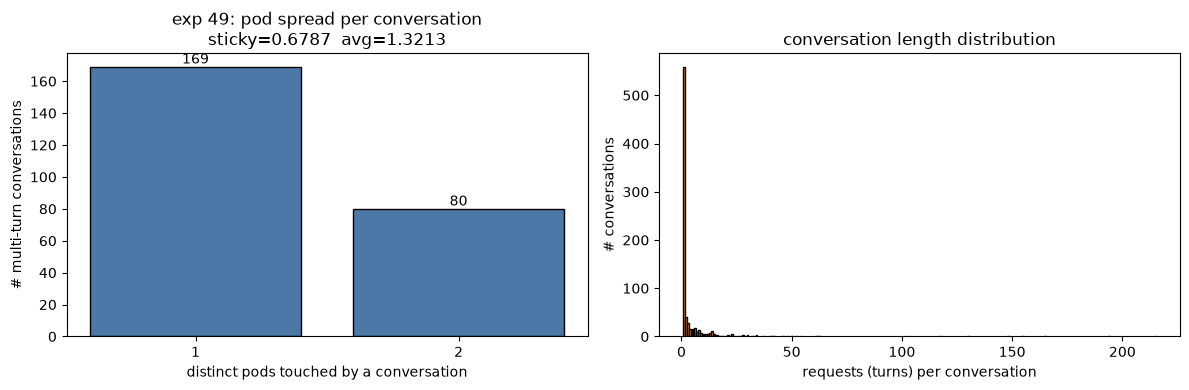

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

if n_multi:
    vc = multi["distinct_endpoints"].value_counts().sort_index()
    ax[0].bar(vc.index.astype(int), vc.values, color="#4C78A8", edgecolor="black")
    ax[0].set_xlabel("distinct pods touched by a conversation")
    ax[0].set_ylabel("# multi-turn conversations")
    ax[0].set_title(f"exp {EXP_ID}: pod spread per conversation\n"
                    f"sticky={summary['sticky_frac']}  avg={summary['avg_distinct_endpoints']}")
    ax[0].set_xticks(vc.index.astype(int))
    for x, y in zip(vc.index.astype(int), vc.values):
        ax[0].text(x, y, str(int(y)), ha="center", va="bottom")

# turns-per-conversation distribution (context: how much stickiness could matter)
tv = per_conv["requests"].value_counts().sort_index()
ax[1].bar(tv.index.astype(int), tv.values, color="#F58518", edgecolor="black")
ax[1].set_xlabel("requests (turns) per conversation")
ax[1].set_ylabel("# conversations")
ax[1].set_title("conversation length distribution")

plt.tight_layout()
plt.show()

## 3. Per-pod load balance

Even with perfect stickiness, hard affinity can pile too many conversations on one
pod. This shows requests + conversations per pod, and the prefix-cache hit fraction
each pod achieved.

,endpoint_id,requests,conversations,kv_hit_frac,matched_tokens
1,vllm-minimax-m2-1,2588,446,0.001546,3072
0,vllm-minimax-m2-0,2177,442,0.054203,46848


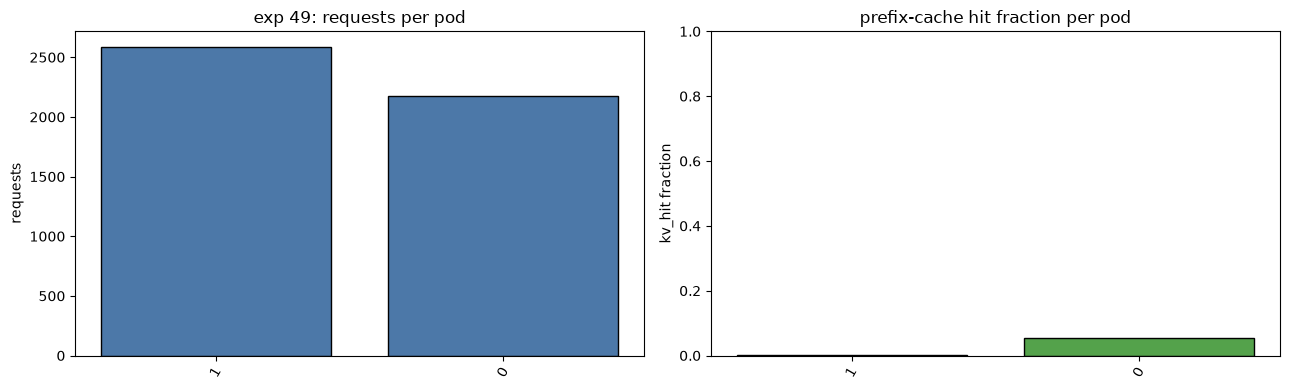

load imbalance: max/mean = 1.09x  (max 2588 vs mean 2382.5 across 2 pods)


In [4]:
per_ep = (
    valid.groupby("endpoint_id")
    .agg(
        requests=("req_id", "size"),
        conversations=("group", "nunique"),
        kv_hit_frac=("kv_hit", lambda s: pd.Series(s).fillna(False).astype(bool).mean()),
        matched_tokens=("matched_tokens", "sum"),
    )
    .reset_index()
    .sort_values("requests", ascending=False)
)
display(per_ep)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
labels = [e.split("-")[-1] if isinstance(e, str) else str(e) for e in per_ep["endpoint_id"]]

ax[0].bar(labels, per_ep["requests"], color="#4C78A8", edgecolor="black")
ax[0].set_ylabel("requests")
ax[0].set_title(f"exp {EXP_ID}: requests per pod")
ax[0].tick_params(axis="x", rotation=60)

if per_ep["kv_hit_frac"].notna().any():
    ax[1].bar(labels, per_ep["kv_hit_frac"], color="#54A24B", edgecolor="black")
    ax[1].set_ylabel("kv_hit fraction")
    ax[1].set_ylim(0, 1)
    ax[1].set_title("prefix-cache hit fraction per pod")
    ax[1].tick_params(axis="x", rotation=60)

plt.tight_layout()
plt.show()

# load-imbalance one-liner
if len(per_ep) > 1:
    r = per_ep["requests"]
    print(f"load imbalance: max/mean = {r.max() / r.mean():.2f}x  "
          f"(max {int(r.max())} vs mean {r.mean():.1f} across {len(per_ep)} pods)")

## 4. Does stickiness pay off? KV hit + TTFT by turn

If affinity works, **later turns** of a conversation should hit the prefix cache
(their history is already resident on that pod) and get **lower TTFT** than turn 0.
A flat/rising TTFT across turns means stickiness is not translating into reuse.

In [5]:
by_turn = df[df["turn_idx"].notna()].copy()
if len(by_turn):
    by_turn["turn_idx"] = by_turn["turn_idx"].astype(int)
    agg = by_turn.groupby("turn_idx").agg(
        n=("req_id", "size"),
        kv_hit_frac=("kv_hit", lambda s: pd.Series(s).fillna(False).astype(bool).mean()),
        ttft_p50=("ttft_s", "median"),
        ttft_mean=("ttft_s", "mean"),
        matched_tokens_mean=("matched_tokens", "mean"),
    ).reset_index()
    # keep turns with a reasonable sample
    agg = agg[agg["n"] >= 3]
    display(agg.head(20))

    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    ax[0].plot(agg["turn_idx"], agg["kv_hit_frac"], marker="o", color="#54A24B")
    ax[0].set_xlabel("turn index within conversation")
    ax[0].set_ylabel("kv_hit fraction")
    ax[0].set_ylim(0, 1)
    ax[0].set_title(f"exp {EXP_ID}: prefix-cache hit vs turn")
    ax[0].grid(alpha=0.3)

    if agg["ttft_p50"].notna().any():
        ax[1].plot(agg["turn_idx"], agg["ttft_p50"], marker="o", label="p50", color="#E45756")
        ax[1].plot(agg["turn_idx"], agg["ttft_mean"], marker="s", label="mean", color="#B279A2")
        ax[1].set_xlabel("turn index within conversation")
        ax[1].set_ylabel("TTFT (s)")
        ax[1].set_title("TTFT vs turn (should drop after turn 0)")
        ax[1].legend()
        ax[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("no turn_idx in this experiment (not a multi-turn run?)")

no turn_idx in this experiment (not a multi-turn run?)


## 5. Sticky vs non-sticky conversations — latency payoff

Direct A/B: conversations that stayed on one pod vs those that bounced. If affinity
helps, sticky conversations should show lower mean TTFT / E2E on their non-first
turns.

In [6]:
if n_multi and by_turn.shape[0]:
    sticky_ids = set(multi.loc[multi["distinct_endpoints"] == 1, "group"])
    spread_ids = set(multi.loc[multi["distinct_endpoints"] > 1, "group"])

    later = by_turn[by_turn["turn_idx"] >= 1].copy()  # turn 0 is always a cold start
    later["bucket"] = np.where(
        later["group"].isin(sticky_ids), "sticky (1 pod)",
        np.where(later["group"].isin(spread_ids), "spread (>1 pod)", "other")
    )
    later = later[later["bucket"] != "other"]

    cmp = later.groupby("bucket").agg(
        turns=("req_id", "size"),
        kv_hit_frac=("kv_hit", lambda s: pd.Series(s).fillna(False).astype(bool).mean()),
        ttft_p50=("ttft_s", "median"),
        ttft_mean=("ttft_s", "mean"),
        e2e_p50=("end_to_end_s", "median"),
        e2e_mean=("end_to_end_s", "mean"),
    )
    display(cmp)
    if len(spread_ids) == 0:
        print("\nNo spread conversations — affinity held for every multi-turn chat, "
              "so there is no non-sticky group to compare against (this is the good case).")
else:
    print("Not enough multi-turn / turn data for a sticky-vs-spread comparison.")

Not enough multi-turn / turn data for a sticky-vs-spread comparison.


## 6. Why realized KV-hit drops even though we *have* hits

Two different "hit" numbers:
- **Nominal (router)** — `kv_hit` / `matched_tokens` in `logs.json`: the router found a
  prefix and pinned the request to a pod. With affinity this stays **high**.
- **Realized (engine)** — `vllm:prefix_cache_hits_total / queries_total` (internal) and
  `vllm:external_prefix_cache_*` (external / Mooncake) from `metrics.jsonl`: KV blocks the
  engine actually reused instead of recomputing.

The collapse we saw is the gap between these two: the router keeps promising hits, but once
`kv_cache_usage_perc` saturates, the engine **evicts** the very prefix blocks it was supposed
to reuse (and LMCache has to reload them), so realized hit rate falls while nominal stays up.

This section overlays the realized internal/external hit rate against KV-cache usage,
waiting queue, and preemptions over the run — the drop should line up with saturation.

prom samples: (27777, 32) | cols: ['ts', 'instance', 'requests_running', 'requests_waiting', 'request_success_per_sec', 'preemptions_per_sec', 'gen_tokens_per_sec', 'prefill_tokens_per_sec', 'prefix_cache_hits_per_sec', 'prefix_cache_queries_per_sec', 'ext_prefix_cache_hits_per_sec', 'ext_prefix_cache_queries_per_sec', 'prompt_tokens_cached_per_sec', 'ttft_seconds_avg', 'e2e_latency_seconds_avg', 'router_queue_length', 'router_admission_rps', 'router_outgoing_rps', 'prefix_cache_hit_rate', 'ext_prefix_cache_hit_rate']


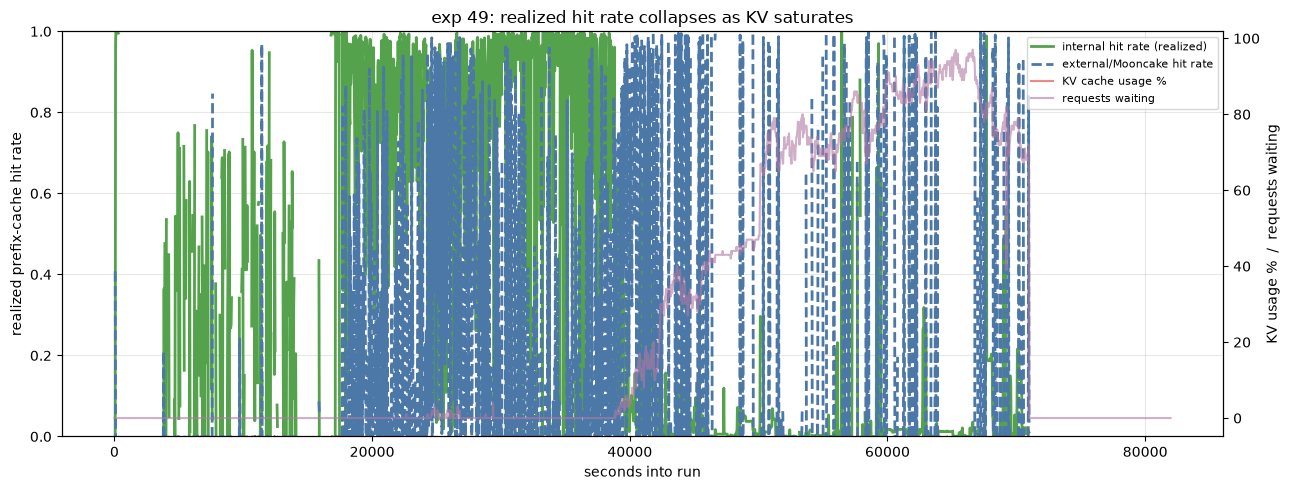

fleet-weighted realized hit rate: internal=0.088  external=0.458


In [7]:
from experiment_analysis import load_experiment_prom_samples

prom = load_experiment_prom_samples(exp_id=EXP_ID, experiments_root=EXPERIMENTS_ROOT)
print("prom samples:", prom.shape, "| cols:", [c for c in prom.columns][:20])


def _fleet_timeseries(prom):
    """Per-tick fleet aggregate: sum rate numerators/denominators across pods,
    then derive hit rate so it is properly request-weighted (not a mean of ratios)."""
    if prom.empty or "ts" not in prom:
        return pd.DataFrame()
    g = prom.groupby("ts")

    def s(col):
        return g[col].sum() if col in prom.columns else pd.Series(0.0, index=g.size().index)

    def m(col):
        return g[col].mean() if col in prom.columns else pd.Series(np.nan, index=g.size().index)

    out = pd.DataFrame({
        "int_hits": s("prefix_cache_hits_per_sec"),
        "int_q": s("prefix_cache_queries_per_sec"),
        "ext_hits": s("ext_prefix_cache_hits_per_sec"),
        "ext_q": s("ext_prefix_cache_queries_per_sec"),
        "kv_usage": m("kv_cache_usage_perc"),
        "waiting": s("requests_waiting"),
        "running": s("requests_running"),
        "preempt": s("preemptions_per_sec"),
    }).reset_index()
    out["internal_hit_rate"] = out["int_hits"] / out["int_q"].replace(0, np.nan)
    out["external_hit_rate"] = out["ext_hits"] / out["ext_q"].replace(0, np.nan)
    # kv_usage may be a fraction (0-1) or percent (0-100); normalise to %
    if out["kv_usage"].max() is not np.nan and out["kv_usage"].max() <= 1.5:
        out["kv_usage"] = out["kv_usage"] * 100.0
    return out


fleet = _fleet_timeseries(prom)
if fleet.empty:
    print("No metrics.jsonl for this experiment - skip §6 (run with metrics enabled).")
else:
    t = pd.to_datetime(fleet["ts"])
    t0 = t.min()
    elapsed = (t - t0).dt.total_seconds()

    fig, ax1 = plt.subplots(figsize=(13, 5))
    ax1.plot(elapsed, fleet["internal_hit_rate"], color="#54A24B", lw=2, label="internal hit rate (realized)")
    if fleet["external_hit_rate"].notna().any():
        ax1.plot(elapsed, fleet["external_hit_rate"], color="#4C78A8", lw=2, ls="--", label="external/Mooncake hit rate")
    ax1.set_ylabel("realized prefix-cache hit rate")
    ax1.set_ylim(0, 1)
    ax1.set_xlabel("seconds into run")

    ax2 = ax1.twinx()
    ax2.plot(elapsed, fleet["kv_usage"], color="#E45756", alpha=0.7, label="KV cache usage %")
    ax2.plot(elapsed, fleet["waiting"], color="#B279A2", alpha=0.6, label="requests waiting")
    ax2.set_ylabel("KV usage %  /  requests waiting")

    l1, lab1 = ax1.get_legend_handles_labels()
    l2, lab2 = ax2.get_legend_handles_labels()
    ax1.legend(l1 + l2, lab1 + lab2, loc="upper right", fontsize=8)
    ax1.set_title(f"exp {EXP_ID}: realized hit rate collapses as KV saturates")
    ax1.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("fleet-weighted realized hit rate: "
          f"internal={fleet['int_hits'].sum() / max(fleet['int_q'].sum(), 1e-9):.3f}  "
          f"external={fleet['ext_hits'].sum() / max(fleet['ext_q'].sum(), 1e-9):.3f}")

## 7. Nominal vs realized, side by side

Two views that tie the router's promise to the engine's delivery:
- **Over time:** router nominal hit fraction (`kv_hit` from `logs.json`, binned by
  `t0_wall`) vs engine realized internal hit rate. Affinity keeps the green router line
  high; the drop is on the engine side.
- **Per request:** `matched_tokens` (how much prefix the router promised) vs TTFT, split by
  early/late in the run. If hits were realized, more matched tokens → lower TTFT. Under the
  collapse, the promised prefix stops paying off (TTFT stays high despite a big match).

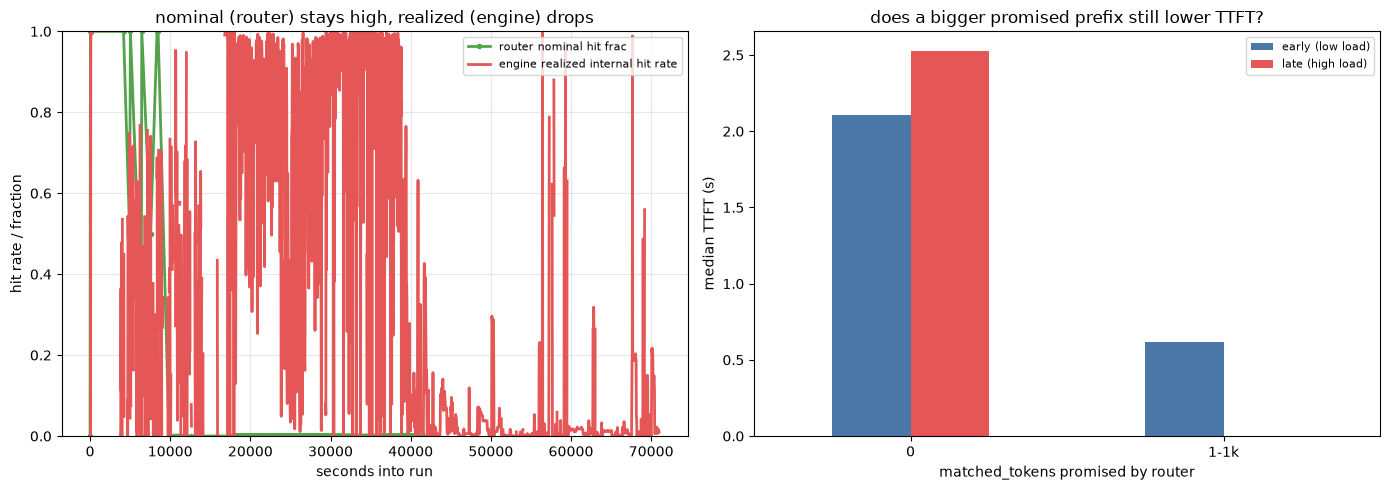

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# --- (a) nominal (router) vs realized (engine) over time ---
r = df[df["t0_wall"].notna()].copy()
if len(r) and r["kv_hit"].notna().any():
    r["rel_s"] = r["t0_wall"] - r["t0_wall"].min()
    bin_s = 5.0
    r["bin"] = (r["rel_s"] // bin_s) * bin_s
    nominal = r.groupby("bin").agg(
        nominal_hit_frac=("kv_hit", lambda s: pd.Series(s).fillna(False).astype(bool).mean()),
        n=("req_id", "size"),
    ).reset_index()
    nominal = nominal[nominal["n"] >= 2]
    ax[0].plot(nominal["bin"], nominal["nominal_hit_frac"], color="#54A24B", lw=2,
               marker="o", ms=3, label="router nominal hit frac")
if not fleet.empty:
    fe = (pd.to_datetime(fleet["ts"]) - pd.to_datetime(fleet["ts"]).min()).dt.total_seconds()
    ax[0].plot(fe, fleet["internal_hit_rate"], color="#E45756", lw=2,
               label="engine realized internal hit rate")
ax[0].set_xlabel("seconds into run")
ax[0].set_ylabel("hit rate / fraction")
ax[0].set_ylim(0, 1)
ax[0].set_title("nominal (router) stays high, realized (engine) drops")
ax[0].legend(fontsize=8)
ax[0].grid(alpha=0.3)

# --- (b) matched_tokens promised vs TTFT paid, early vs late ---
m = df[df["matched_tokens"].notna() & df["ttft_s"].notna() & df["t0_wall"].notna()].copy()
if len(m) > 10:
    half = m["t0_wall"].median()
    m["phase"] = np.where(m["t0_wall"] <= half, "early (low load)", "late (high load)")
    edges = [-1, 0, 1000, 5000, 20000, 1e12]
    labels = ["0", "1-1k", "1k-5k", "5k-20k", ">20k"]
    m["mt_bucket"] = pd.cut(m["matched_tokens"].fillna(0), bins=edges, labels=labels)
    piv = m.groupby(["mt_bucket", "phase"], observed=True)["ttft_s"].median().unstack()
    piv.plot(kind="bar", ax=ax[1], color={"early (low load)": "#4C78A8", "late (high load)": "#E45756"})
    ax[1].set_xlabel("matched_tokens promised by router")
    ax[1].set_ylabel("median TTFT (s)")
    ax[1].set_title("does a bigger promised prefix still lower TTFT?")
    ax[1].tick_params(axis="x", rotation=0)
    ax[1].legend(title="", fontsize=8)
else:
    ax[1].text(0.5, 0.5, "not enough matched_tokens+ttft data", ha="center", va="center")

plt.tight_layout()
plt.show()

## 8. Per-request KV-hit fraction over time (find the sudden drop)

Zooms into the router-reported `kv_hit` fraction across the run at fine time
resolution, with a rolling average, and **auto-detects the drop**: it computes an
early-run baseline and flags (a) the steepest bin-to-bin fall and (b) the first time
the rolling hit fraction stays below `DROP_FRAC x baseline`. The request rate is
overlaid so you can see whether the drop coincides with the load ramp.

Knobs: `BIN_S` (time bin width), `ROLL` (rolling window in bins), `DROP_FRAC`
(what counts as "collapsed" relative to baseline).

baseline hit frac (first 10 bins): 0.800
threshold for 'collapsed' (0.6x baseline): 0.480
steepest drop at ~3822s
sustained collapse begins at ~0s (mean hit frac after: 0.031, so 0.800 -> 0.031)


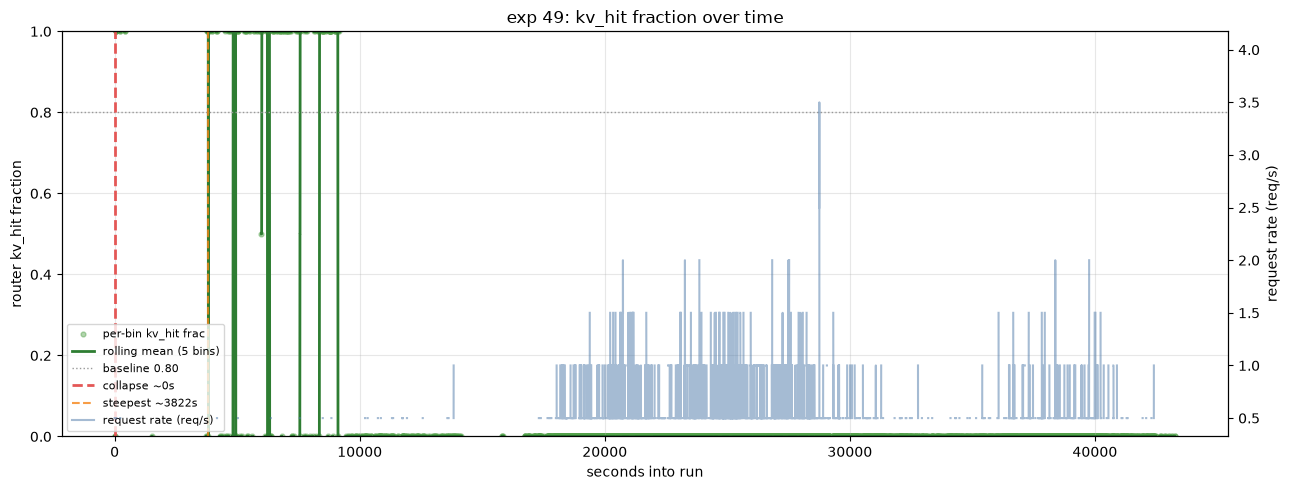

In [9]:
BIN_S = 2.0        # time-bin width (s)
ROLL = 5           # rolling window (# bins)
DROP_FRAC = 0.6    # "collapsed" = rolling hit frac below this * baseline
BASELINE_BINS = 10 # # of early bins used for the baseline

d = df[df["t0_wall"].notna()].copy()
if not len(d) or not d["kv_hit"].notna().any():
    print("No t0_wall / kv_hit in logs.json — cannot build the time series.")
else:
    d["rel_s"] = d["t0_wall"] - d["t0_wall"].min()
    d["kv_hit_b"] = d["kv_hit"].fillna(False).astype(bool)
    d["bin"] = (d["rel_s"] // BIN_S) * BIN_S

    ts = d.groupby("bin").agg(
        hit_frac=("kv_hit_b", "mean"),
        n=("req_id", "size"),
        matched_mean=("matched_tokens", "mean"),
    ).reset_index()
    # reindex onto a regular grid so gaps don't hide a drop
    grid = np.arange(0, ts["bin"].max() + BIN_S, BIN_S)
    ts = ts.set_index("bin").reindex(grid)
    ts.index.name = "bin"
    ts = ts.reset_index()
    ts["req_per_s"] = ts["n"] / BIN_S
    ts["roll"] = ts["hit_frac"].rolling(ROLL, min_periods=1).mean()

    baseline = ts["hit_frac"].dropna().iloc[:BASELINE_BINS].mean()

    # (a) steepest single-bin fall in the rolling series
    diff = ts["roll"].diff()
    steep_i = diff.idxmin() if diff.notna().any() else None
    steep_t = ts["bin"].iloc[steep_i] if steep_i is not None else None

    # (b) first sustained drop below DROP_FRAC * baseline (2 consecutive bins)
    thr = DROP_FRAC * baseline
    below = ts["roll"] < thr
    drop_t = None
    for i in range(len(below) - 1):
        if bool(below.iloc[i]) and bool(below.iloc[i + 1]):
            drop_t = ts["bin"].iloc[i]
            break

    after = ts.loc[ts["bin"] >= drop_t, "hit_frac"].mean() if drop_t is not None else None
    print(f"baseline hit frac (first {BASELINE_BINS} bins): {baseline:.3f}")
    print(f"threshold for 'collapsed' ({DROP_FRAC}x baseline): {thr:.3f}")
    print(f"steepest drop at ~{steep_t:.0f}s" if steep_t is not None else "steepest drop: n/a")
    if drop_t is not None:
        print(f"sustained collapse begins at ~{drop_t:.0f}s "
              f"(mean hit frac after: {after:.3f}, so {baseline:.3f} -> {after:.3f})")
    else:
        print("no sustained collapse detected at current DROP_FRAC")

    fig, ax1 = plt.subplots(figsize=(13, 5))
    ax1.scatter(ts["bin"], ts["hit_frac"], s=12, color="#54A24B", alpha=0.45, label="per-bin kv_hit frac")
    ax1.plot(ts["bin"], ts["roll"], color="#2E7D32", lw=2, label=f"rolling mean ({ROLL} bins)")
    ax1.axhline(baseline, color="#999999", ls=":", lw=1, label=f"baseline {baseline:.2f}")
    if drop_t is not None:
        ax1.axvline(drop_t, color="#E45756", ls="--", lw=2, label=f"collapse ~{drop_t:.0f}s")
    if steep_t is not None and (drop_t is None or abs(steep_t - drop_t) > BIN_S):
        ax1.axvline(steep_t, color="#F58518", ls="--", lw=1.5, alpha=0.8, label=f"steepest ~{steep_t:.0f}s")
    ax1.set_ylabel("router kv_hit fraction")
    ax1.set_ylim(0, 1)
    ax1.set_xlabel("seconds into run")

    ax2 = ax1.twinx()
    ax2.plot(ts["bin"], ts["req_per_s"], color="#4C78A8", alpha=0.5, label="request rate (req/s)")
    ax2.set_ylabel("request rate (req/s)")

    l1, la1 = ax1.get_legend_handles_labels()
    l2, la2 = ax2.get_legend_handles_labels()
    ax1.legend(l1 + l2, la1 + la2, loc="lower left", fontsize=8)
    ax1.set_title(f"exp {EXP_ID}: kv_hit fraction over time")
    ax1.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## What to send back

Screenshot these for the decision:
1. The **summary JSON** from §1 (`sticky_frac`, `avg_distinct_endpoints`, `overall_kv_hit_frac`).
2. §2 histogram (pod spread per conversation).
3. §3 per-pod table + bars (load balance + per-pod hit fraction).
4. §4 KV-hit and TTFT vs turn.
5. §5 sticky-vs-spread table (if any spread existed).
6. §6 realized hit rate vs KV-usage/waiting over time.
7. §7 nominal-vs-realized (both plots).
8. §8 per-request kv_hit fraction over time + the detected drop time.

Rough read:
- `sticky_frac >= ~0.98` and `avg_distinct_endpoints ~1.0` → hard affinity is doing its job.
- KV-hit fraction climbing after turn 0 and TTFT dropping after turn 0 → stickiness is turning into real prefix reuse.
- If stickiness is high but per-pod load is very skewed (`max/mean` large), that is the thing to watch, not stickiness itself.

Why the hit rate drops despite having hits (§6–§7):
- If the **router nominal** line (green, §7a) stays high but the **engine realized** line
  (red) falls, the hits are being *promised and then evicted* — not a routing/affinity bug.
- The realized drop lining up with `kv_cache_usage_perc` hitting ~90%+ and `requests_waiting`
  climbing (§6) is the saturation/eviction signature — the GPU KV has no room to keep the
  prefix blocks, so LMCache reloads them (the NDS thrash from the log analysis).
- In §7b, if `late (high load)` TTFT no longer falls as `matched_tokens` grows, the promised
  prefix stopped paying off — the concrete "we have hits but they don't help" evidence.
- Fix direction is the same as the config change: bigger local cache + capped concurrency so
  the engine can *retain* the prefix the router keeps sending it.

## 9. Machine-readable dump (paste this back for analysis)

Run this last. It **recomputes every number** from `df` (and the engine metrics from
§6 if you ran it) and prints one JSON block. Copy the whole block between the marker
lines and paste it back into chat — it contains the stickiness summary, per-pod table,
per-turn table, sticky-vs-spread, the full per-bin `kv_hit` time series + detected
drop, and the engine realized hit-rate/KV-usage/waiting series. No plots needed.

In [10]:
import json as _json


def _f(x, nd=4):
    try:
        if x is None:
            return None
        xf = float(x)
        return None if np.isnan(xf) else round(xf, nd)
    except Exception:
        return None


REPORT = {
    "exp_id": EXP_ID,
    "experiments_root": EXPERIMENTS_ROOT,
    "n_requests": int(len(df)),
    "n_conversations": int(df["group"].nunique()),
    "n_endpoints": int(df["endpoint_id"].nunique()),
}

# --- stickiness ---
v = df[df["endpoint_id"].notna() & df["group"].notna()].copy()
pc = v.groupby("group").agg(
    requests=("req_id", "size"),
    distinct_endpoints=("endpoint_id", "nunique"),
).reset_index()
mt = pc[pc["requests"] > 1]
REPORT["stickiness"] = {
    "conversations": int(len(pc)),
    "multi_turn_conversations": int(len(mt)),
    "sticky_conversations": int((mt["distinct_endpoints"] == 1).sum()) if len(mt) else 0,
    "sticky_frac": _f((mt["distinct_endpoints"] == 1).mean()) if len(mt) else None,
    "avg_distinct_endpoints": _f(mt["distinct_endpoints"].mean()) if len(mt) else None,
    "max_distinct_endpoints": int(mt["distinct_endpoints"].max()) if len(mt) else None,
    "overall_kv_hit_frac": _f(v["kv_hit"].fillna(False).astype(bool).mean()) if v["kv_hit"].notna().any() else None,
}

# --- per endpoint ---
pe = v.groupby("endpoint_id").agg(
    requests=("req_id", "size"),
    conversations=("group", "nunique"),
    kv_hit_frac=("kv_hit", lambda s: pd.Series(s).fillna(False).astype(bool).mean()),
    matched_tokens=("matched_tokens", "sum"),
).reset_index().sort_values("requests", ascending=False)
pe["kv_hit_frac"] = pe["kv_hit_frac"].map(_f)
pe["matched_tokens"] = pe["matched_tokens"].map(lambda x: int(x) if pd.notna(x) else None)
REPORT["per_endpoint"] = pe.to_dict("records")
if len(pe) > 1:
    REPORT["load_imbalance_max_over_mean"] = _f(pe["requests"].max() / pe["requests"].mean(), 2)

# --- by turn ---
bt = df[df["turn_idx"].notna()].copy()
if len(bt):
    bt["turn_idx"] = bt["turn_idx"].astype(int)
    ag = bt.groupby("turn_idx").agg(
        n=("req_id", "size"),
        kv_hit_frac=("kv_hit", lambda s: pd.Series(s).fillna(False).astype(bool).mean()),
        ttft_p50=("ttft_s", "median"),
        ttft_mean=("ttft_s", "mean"),
        matched_tokens_mean=("matched_tokens", "mean"),
    ).reset_index()
    ag = ag[ag["n"] >= 3]
    for c in ["kv_hit_frac", "ttft_p50", "ttft_mean", "matched_tokens_mean"]:
        ag[c] = ag[c].map(_f)
    REPORT["by_turn"] = ag.to_dict("records")

# --- sticky vs spread (non-first turns) ---
if len(mt) and len(bt):
    sids = set(mt.loc[mt["distinct_endpoints"] == 1, "group"])
    spids = set(mt.loc[mt["distinct_endpoints"] > 1, "group"])
    lt = bt[bt["turn_idx"] >= 1].copy()
    lt["bucket"] = np.where(lt["group"].isin(sids), "sticky",
                            np.where(lt["group"].isin(spids), "spread", "other"))
    lt = lt[lt["bucket"] != "other"]
    if len(lt):
        cs = lt.groupby("bucket").agg(
            turns=("req_id", "size"),
            kv_hit_frac=("kv_hit", lambda s: pd.Series(s).fillna(False).astype(bool).mean()),
            ttft_p50=("ttft_s", "median"),
            ttft_mean=("ttft_s", "mean"),
            e2e_p50=("end_to_end_s", "median"),
            e2e_mean=("end_to_end_s", "mean"),
        ).reset_index()
        for c in ["kv_hit_frac", "ttft_p50", "ttft_mean", "e2e_p50", "e2e_mean"]:
            cs[c] = cs[c].map(_f)
        REPORT["sticky_vs_spread"] = cs.to_dict("records")

# --- kv_hit time series + drop detection ---
dd = df[df["t0_wall"].notna()].copy()
if len(dd) and dd["kv_hit"].notna().any():
    _BIN = 2.0
    dd["rel_s"] = dd["t0_wall"] - dd["t0_wall"].min()
    dd["kv_hit_b"] = dd["kv_hit"].fillna(False).astype(bool)
    dd["bin"] = (dd["rel_s"] // _BIN) * _BIN
    tss = dd.groupby("bin").agg(
        hit_frac=("kv_hit_b", "mean"),
        n=("req_id", "size"),
        matched_mean=("matched_tokens", "mean"),
        ttft_p50=("ttft_s", "median"),
    ).reset_index()
    tss["roll"] = tss["hit_frac"].rolling(5, min_periods=1).mean()
    base = tss["hit_frac"].iloc[:10].mean()
    thr = 0.6 * base
    below = tss["roll"] < thr
    drop = None
    for i in range(len(below) - 1):
        if bool(below.iloc[i]) and bool(below.iloc[i + 1]):
            drop = float(tss["bin"].iloc[i])
            break
    REPORT["kv_hit_timeseries"] = {
        "bin_s": _BIN,
        "baseline_hit_frac": _f(base),
        "collapse_threshold": _f(thr),
        "collapse_start_s": _f(drop, 1),
        "hit_frac_after_collapse": _f(tss.loc[tss["bin"] >= drop, "hit_frac"].mean()) if drop is not None else None,
        "run_duration_s": _f(tss["bin"].max(), 1),
        "bins": [
            {"t": _f(b, 1), "hit_frac": _f(h), "roll": _f(r), "n": int(n),
             "matched_mean": _f(mm, 1), "ttft_p50": _f(tp)}
            for b, h, r, n, mm, tp in zip(tss["bin"], tss["hit_frac"], tss["roll"],
                                          tss["n"], tss["matched_mean"], tss["ttft_p50"])
        ],
    }

# --- engine realized (from §6 fleet, if it was run) ---
fl = globals().get("fleet")
if fl is not None and not getattr(fl, "empty", True):
    fl2 = fl.copy()
    fl2["elapsed_s"] = (pd.to_datetime(fl2["ts"]) - pd.to_datetime(fl2["ts"]).min()).dt.total_seconds()
    REPORT["engine_realized"] = {
        "internal_hit_rate_weighted": _f(fl2["int_hits"].sum() / max(fl2["int_q"].sum(), 1e-9)),
        "external_hit_rate_weighted": _f(fl2["ext_hits"].sum() / max(fl2["ext_q"].sum(), 1e-9)),
        "kv_usage_max": _f(fl2["kv_usage"].max(), 1),
        "waiting_max": _f(fl2["waiting"].max(), 1),
        "series": [
            {"t": _f(e, 1), "internal_hit_rate": _f(ih), "external_hit_rate": _f(eh),
             "kv_usage": _f(ku, 1), "waiting": _f(w, 1), "running": _f(rn, 1), "preempt_per_s": _f(pp)}
            for e, ih, eh, ku, w, rn, pp in zip(
                fl2["elapsed_s"], fl2["internal_hit_rate"], fl2["external_hit_rate"],
                fl2["kv_usage"], fl2["waiting"], fl2["running"], fl2["preempt"])
        ],
    }
else:
    REPORT["engine_realized"] = None  # run §6 (metrics.jsonl) to populate

print("=" * 72)
print("COPY EVERYTHING BETWEEN THE MARKERS BELOW AND PASTE BACK FOR ANALYSIS")
print("===BEGIN REPORT===")
print(_json.dumps(REPORT, indent=2, default=str))
print("===END REPORT===")

COPY EVERYTHING BETWEEN THE MARKERS BELOW AND PASTE BACK FOR ANALYSIS
===BEGIN REPORT===
{
  "exp_id": 49,
  "experiments_root": "/home/data/saeid/experiments",
  "n_requests": 4765,
  "n_conversations": 808,
  "n_endpoints": 2,
  "stickiness": {
    "conversations": 808,
    "multi_turn_conversations": 249,
    "sticky_conversations": 169,
    "sticky_frac": 0.6787,
    "avg_distinct_endpoints": 1.3213,
    "max_distinct_endpoints": 2,
    "overall_kv_hit_frac": 0.0256
  },
  "per_endpoint": [
    {
      "endpoint_id": "vllm-minimax-m2-1",
      "requests": 2588,
      "conversations": 446,
      "kv_hit_frac": 0.0015,
      "matched_tokens": 3072
    },
    {
      "endpoint_id": "vllm-minimax-m2-0",
      "requests": 2177,
      "conversations": 442,
      "kv_hit_frac": 0.0542,
      "matched_tokens": 46848
    }
  ],
  "load_imbalance_max_over_mean": 1.09,
  "kv_hit_timeseries": {
    "bin_s": 2.0,
    "baseline_hit_frac": 0.8,
    "collapse_threshold": 0.48,
    "collapse_start_

## 10. Is `kv_hit=0` a real miss or a missing emission?

Distinguishes three cases per request so we know whether the zero is genuine or an
emission/coverage gap:
- `kv_hit` **absent** (not emitted / not joined by `router_log_collector`) — my earlier
  `overall_kv_hit_frac` counted these as misses, which is wrong.
- `total_blocks == 0` → the router never registered block hashes for the request, so
  `prefix_len` is structurally 0 (it *cannot* report a hit) — a coverage gap.
- `total_blocks > 0` but `kv_hits_len == 0` → blocks were registered but the router's
  prefix model had none cached on that endpoint — router-model decay, not the engine.

Split first-600 s vs after so we can see if registration stops after warmup.

In [ ]:
import json as _json

kh = pd.to_numeric(df.get("kv_hits_len"), errors="coerce")
tb = pd.to_numeric(df.get("total_blocks"), errors="coerce")
present = df["kv_hit"].notna()
mt = pd.to_numeric(df.get("matched_tokens"), errors="coerce")

DIAG = {
    "n_requests": int(len(df)),
    "kv_hit_present": int(present.sum()),
    "kv_hit_absent": int((~present).sum()),
    "kv_hit_true": int((df["kv_hit"] == True).sum()),
    "kv_hit_false_present": int(((df["kv_hit"] == False)).sum()),
    "total_blocks_gt0": int((tb > 0).sum()),
    "total_blocks_zero_or_nan": int((~(tb > 0)).sum()),
    "kv_hits_len_gt0": int((kh > 0).sum()),
    "matched_tokens_sum": int(mt.fillna(0).sum()),
    # of the requests where blocks WERE registered, how often did the router see a hit?
    "hit_rate_where_blocks_registered": (
        round(float((kh[tb > 0] > 0).mean()), 4) if (tb > 0).any() else None
    ),
    # corrected hit rate: only over requests where kv_hit was actually emitted
    "kv_hit_frac_over_emitted": (
        round(float((df.loc[present, "kv_hit"] == True).mean()), 4) if present.any() else None
    ),
}

# early (warmup) vs later — did block registration stop after warmup?
d = df[df["t0_wall"].notna()].copy()
if len(d):
    d["rel_s"] = d["t0_wall"] - d["t0_wall"].min()
    for phase, m in [("first_600s", d["rel_s"] <= 600), ("after_600s", d["rel_s"] > 600)]:
        sub = d[m]
        tbi = pd.to_numeric(sub.get("total_blocks"), errors="coerce")
        khi = pd.to_numeric(sub.get("kv_hits_len"), errors="coerce")
        pr = sub["kv_hit"].notna()
        DIAG[phase] = {
            "n": int(len(sub)),
            "kv_hit_emitted_frac": round(float(pr.mean()), 4) if len(sub) else None,
            "blocks_registered_frac": round(float((tbi > 0).mean()), 4) if len(sub) else None,
            "kv_hits_len_gt0_frac": round(float((khi > 0).mean()), 4) if len(sub) else None,
        }

print("===BEGIN KV_EMISSION_DIAG===")
print(_json.dumps(DIAG, indent=2, default=str))
print("===END KV_EMISSION_DIAG===")